<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/04_8_%EC%A0%84%EB%AC%B8%EA%B0%80_%EC%A7%80%EC%8B%9D_%ED%99%9C%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- 특성 공학은 특정한 애플리케이션을 위해 전문가의 지식을 사용할 수 있는 중요한 영역
- 작업에 내재된 사전 지식이 특성으로 추가될 수 있다면 머신러닝 알고리즘에 도움이 됨
- 특성이 추가된다고 머신러닝 알고리즘이 반드시 그 특성을 사용하는 것은 아님
- ✏️ 풀려는 문제: 특정 날짜와 시간에 앤디 집 앞에 있는 자전거를 사람들이 얼마나 대여할 것인지를 예측 ➡️ 앤디가 빌릴 자전거가 남아 있는지 알고자 함

In [3]:
# 데이터 로드

citibike = mglearn.datasets.load_citibike()
print(f"시티 바이트 데이터: \n{citibike.head()}")

시티 바이트 데이터: 
starttime
2015-08-01 00:00:00     3
2015-08-01 03:00:00     0
2015-08-01 06:00:00     9
2015-08-01 09:00:00    41
2015-08-01 12:00:00    39
Freq: 3h, Name: one, dtype: int64


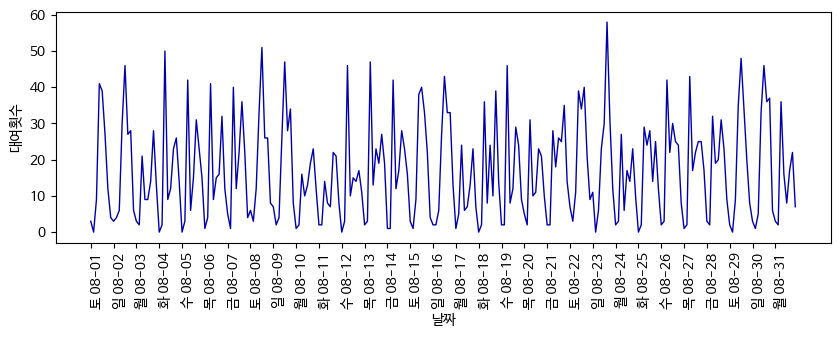

In [4]:
# 한 시티바이크 대여소에서 한 달간 자전거가 대여된 횟수

plt.figure(figsize=(10, 3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(),
                       freq="D")
week = ["일", "월", "화", "수", "목", "금", "토"]
xticks_name = [week[int(w)]+d for w, d in zip(xticks.strftime("%w"),
                                              xticks.strftime(" %m-%d"))]
plt.xticks(xticks, xticks_name, rotation=90, ha="left")
plt.plot(citibike, linewidth=1)
plt.xlabel("날짜")
plt.ylabel("대여횟수")
plt.show()

- 시계열 데이터: 어떤 날짜까지의 모든 데이터를 훈련 세트로 하고, 그 날짜 이후의 모든 데이터를 테스트 세트로 사용

## 01 POSIX 시간 사용
- POSIX 시간: `1970년 1월 1일 00:00:00`부터 경과한 시간을 초로 나타낸 시간
- 날짜와 시간을 하나의 숫자로 표현한 특성을 사용

In [16]:
# 타깃 값 추출 (대여 횟수)
y = citibike.values
# POSIX 시간을 10**9로 나누어 변환
X = citibike.index.astype("int64").values.reshape(-1, 1) // 10**9

In [17]:
# 처음 184개 (23일치) 데이터가 훈련 세트, 나머지는 테스트 세트
n_train = 184

# 주어진 특성을 사용하여 평가하고 그래프 그리기
def eval_on_features(features, target, regressor):
  X_train, X_test = features[:n_train], features[n_train:]
  y_train, y_test = target[:n_train], target[n_train:]

  regressor.fit(X_train, y_train)
  print(f"테스트 세트 R^2: {round(regressor.score(X_test, y_test), 2)}")

  y_pred = regressor.predict(X_test)
  y_pred_train = regressor.predict(X_train)

  plt.figure(figsize=(10, 3))

  plt.xticks(range(0, len(X), 8), xticks_name, rotation=90, ha="left")

  plt.plot(range(n_train), y_train, label="훈련")
  plt.plot(range(n_train), y_pred_train, "--", label="훈련 예측")
  plt.plot(range(n_train, len(y_test) + n_train), y_test, "-", label="테스트")
  plt.plot(range(n_train, len(y_test)+n_train), y_pred, "--", label="테스트 예측")

  plt.legend(loc=(1.01, 0))
  plt.xlabel("날짜")
  plt.ylabel("대여횟수")
  plt.show()

테스트 세트 R^2: -0.04


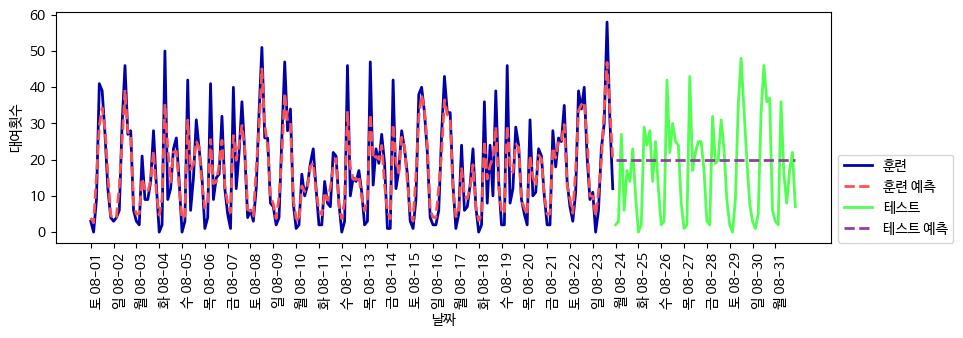

In [18]:
# POSIX 시간만 사용하여 만든 랜덤 포레스트의 예측
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=100, random_state=0)
eval_on_features(X, y, regressor)

- 점수가 매우 낮은 이유: 랜덤 포레스트와 특성 사이의 조합
  - 테스트 세트에 있는 데이터 포인트는 훈련 세트에 있는 모든 데이터보다 뒤의 시간
  - ✨ 트리 모델인 랜덤 포레스트는 훈련 세트에 있는 특성의 범위 밖으로 **외삽**할 수 있는 능력이 없음
  - ➡️ 테스트 세트와 가장 가까이 있는 마지막 훈련 세트 데이터의 타깃 값을 예측으로 사용


## 02 전문가 지식 사용


테스트 세트 R^2: 0.6


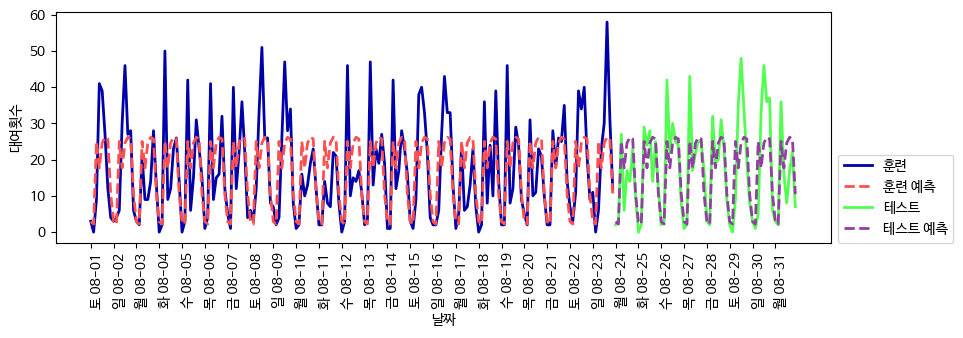

In [19]:
# 시간만을 사용하여 만든 랜덤 포레스트의 예측

X_hour = citibike.index.hour.values.reshape(-1, 1)
eval_on_features(X_hour, y, regressor)

테스트 세트 R^2: 0.84


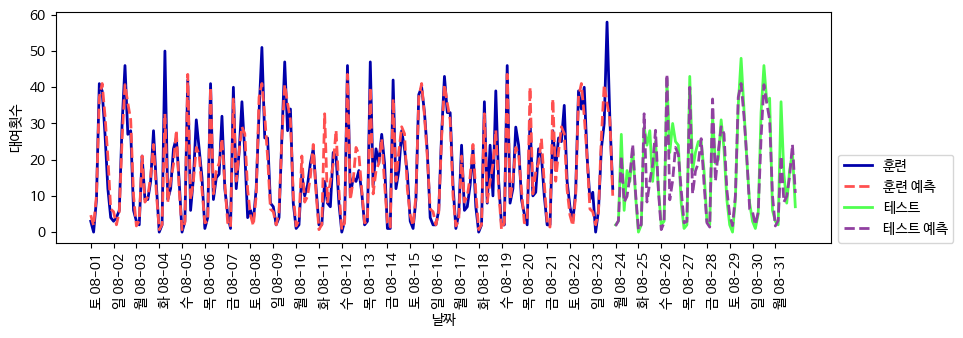

In [20]:
# 시간과 요일 특성을 사용해 만든 랜덤 포레스트의 예측

X_hour_week = np.hstack([citibike.index.dayofweek.values.reshape(-1, 1),
                         citibike.index.hour.values.reshape(-1, 1)])
eval_on_features(X_hour_week, y, regressor)

테스트 세트 R^2: 0.13


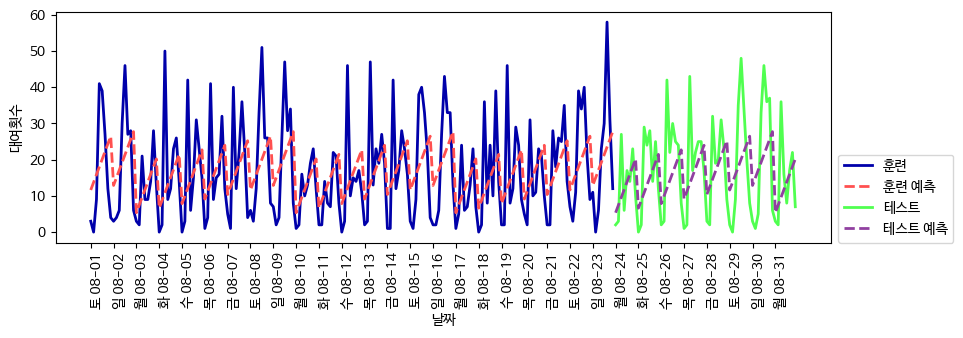

In [21]:
# 시간과 요일 특성을 사용하여 만든 선형 회귀의 예측
from sklearn.linear_model import LinearRegression

eval_on_features(X_hour_week, y, LinearRegression())

- 성능이 안 좋은 이유: 요일과 시간이 정수로 인코딩되어 있어 연속형 변수로 해석되기 때문

In [26]:
# OneHotEncoder를 사용하여 정수형을 범주형 변수로 해석
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()
X_hour_week_onehot = enc.fit_transform(X_hour_week).toarray()
X_hour_week_onehot[:5]

array([[0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

테스트 세트 R^2: 0.62


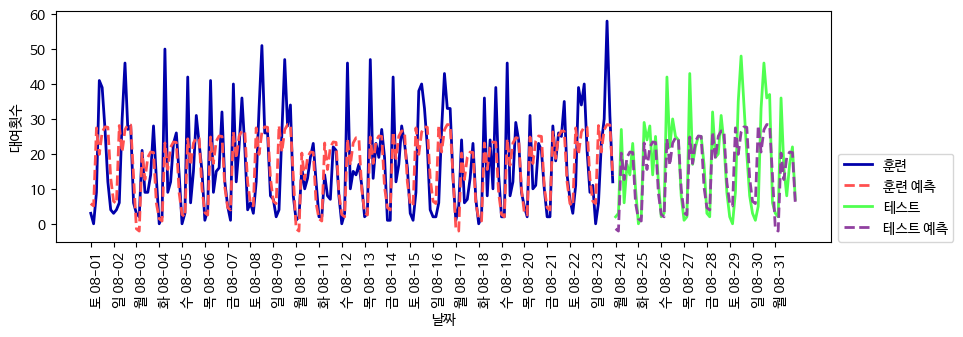

In [27]:
# 시간과 요일의 원-핫 인코딩을 사용해 만든 선형 회귀의 예측
from sklearn.linear_model import Ridge

eval_on_features(X_hour_week_onehot, y, Ridge())

- 요일마다 하나의 계수를 학습하고, 시간마다도 하나의 계수를 학습 ➡️ 시간 패턴이 모든 날에 걸쳐 공유됨
- 상호작용 특성을 사용하면 시간과 요일의 조합별 계수 학습 가능

테스트 세트 R^2: 0.85


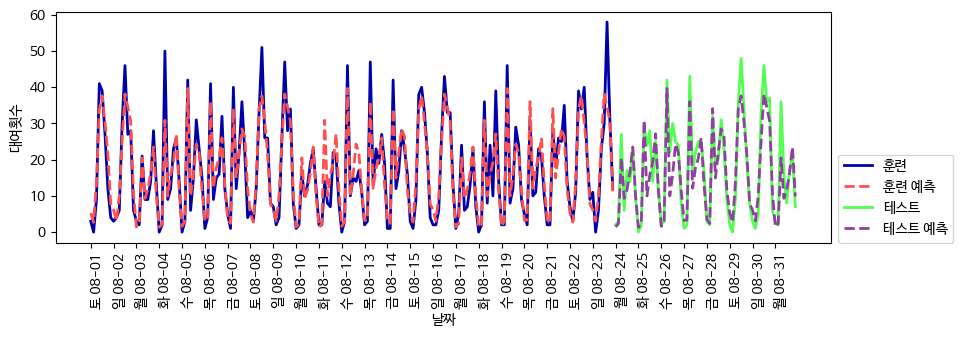

In [28]:
# 시간과 요일의 곱을 특성으로 사용해서 만든 선형 회귀의 예측
from sklearn.preprocessing import PolynomialFeatures

poly_transformer = PolynomialFeatures(degree=2, interaction_only=True,
                                      include_bias=False)
X_hour_week_onehot_poly = poly_transformer.fit_transform(X_hour_week_onehot)
lr = Ridge()
eval_on_features(X_hour_week_onehot_poly, y, lr)

- 👉 무엇이 학습되었는지가 명확해짐: 각 날짜와 시간에 대해 하나의 계수를 학습

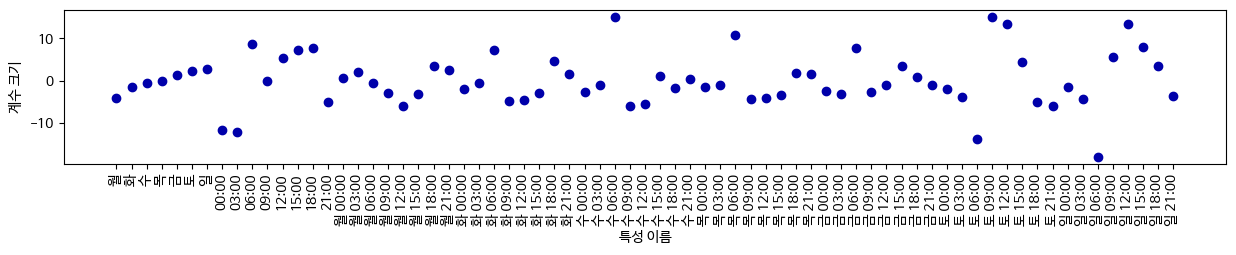

In [30]:
# 시간과 요일의 곱을 사용한 선형 모델의 계수

hour = ["%02d:00" % i for i in range(0, 24, 3) ]
day = ["월", "화", "수", "목", "금", "토", "일"]
features = day + hour

features_poly = poly_transformer.get_feature_names_out(features)
features_nonzero = np.array(features_poly)[lr.coef_ != 0]
coef_nonzero = lr.coef_[lr.coef_ != 0]

plt.figure(figsize=(15, 2))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel("특성 이름")
plt.ylabel("계수 크기")
plt.show()